# RL Matrix Game - Training Analysis

This notebook visualizes the training performance of the Q-Learning agent.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [106]:
# Load training metrics
df = pd.read_csv('training_metrics.csv')
df.head()

,episode,reward,epsilon,rl_wins,heuristic_wins,ties,rolling_win_rate
0,0,-7.0,1.000000,1,0,0,1.00
1,1,-7.0,0.999500,2,0,0,1.00
2,2,-7.0,0.999000,3,0,0,1.00
3,3,-5.0,0.998501,3,1,0,0.75
4,4,-7.0,0.998001,4,1,0,0.80


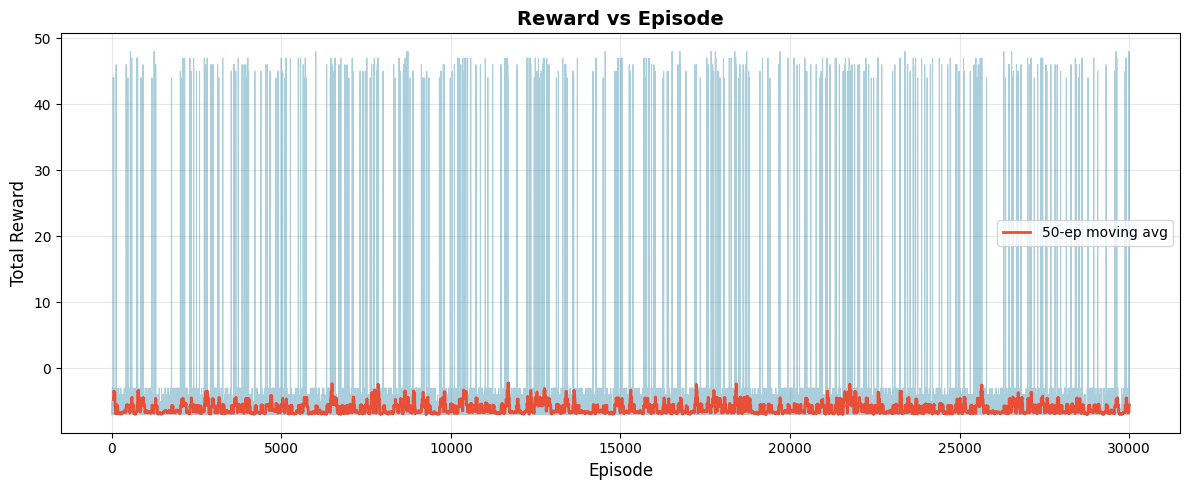

In [107]:
# Plot 1: Reward vs Episode
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['episode'], df['reward'], alpha=0.4, color='#2E86AB', linewidth=0.8)
rolling = df['reward'].rolling(50).mean()
ax.plot(df['episode'], rolling, color='#E94F37', linewidth=2, label='50-ep moving avg')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Reward vs Episode', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

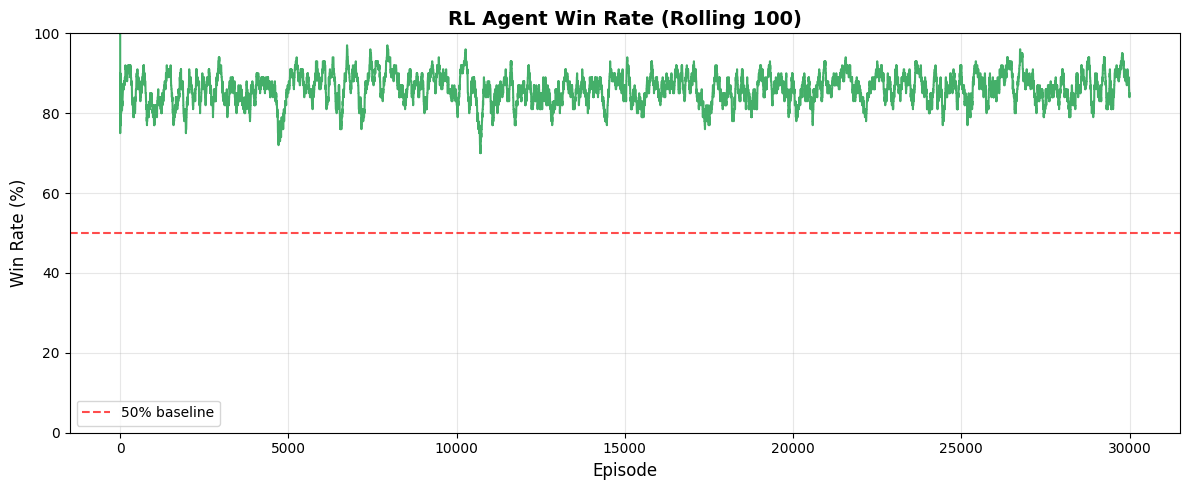

In [108]:
# Plot 2: Win Rate (Rolling Average)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['episode'], df['rolling_win_rate'] * 100, color='#44AF69', linewidth=1.5)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% baseline')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('RL Agent Win Rate (Rolling 100)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

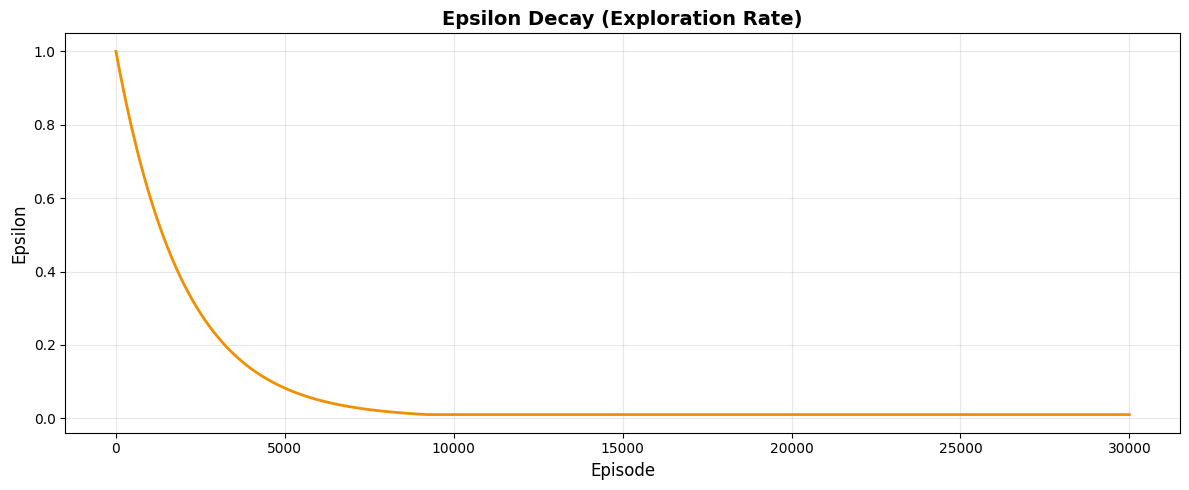

In [109]:
# Plot 3: Epsilon Decay
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['episode'], df['epsilon'], color='#F18F01', linewidth=2)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Epsilon', fontsize=12)
ax.set_title('Epsilon Decay (Exploration Rate)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

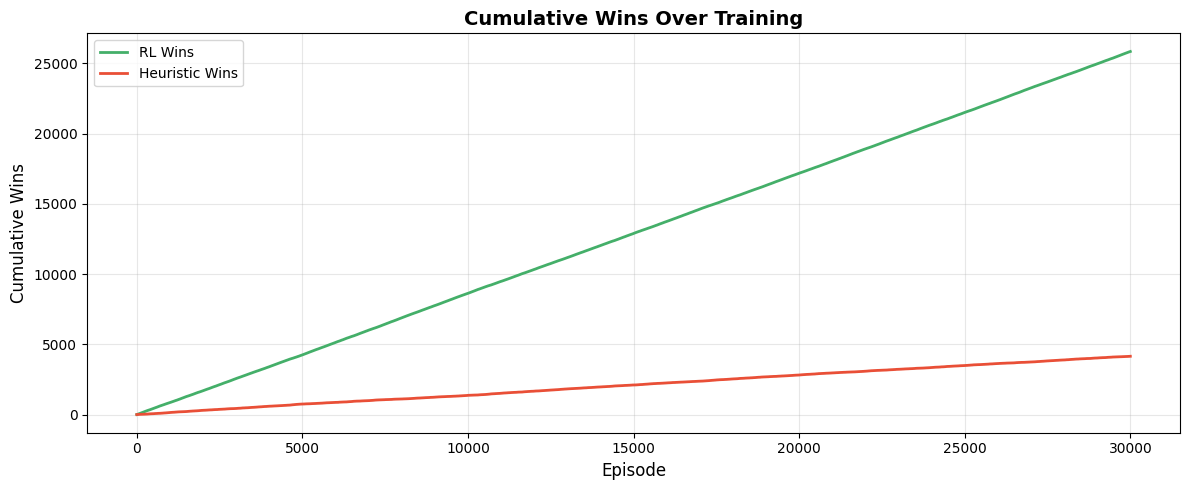

In [110]:
# Plot 4: Cumulative Wins
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['episode'], df['rl_wins'], color='#44AF69', linewidth=2, label='RL Wins')
ax.plot(df['episode'], df['heuristic_wins'], color='#E94F37', linewidth=2, label='Heuristic Wins')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Cumulative Wins', fontsize=12)
ax.set_title('Cumulative Wins Over Training', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [111]:
# Summary Statistics
total = df['rl_wins'].iloc[-1] + df['heuristic_wins'].iloc[-1] + df['ties'].iloc[-1]
rl_pct = 100 * df['rl_wins'].iloc[-1] / total
h_pct = 100 * df['heuristic_wins'].iloc[-1] / total
tie_pct = 100 * df['ties'].iloc[-1] / total

print("="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Total Episodes: {len(df)}")
print(f"RL Wins: {df['rl_wins'].iloc[-1]} ({rl_pct:.1f}%)")
print(f"Heuristic Wins: {df['heuristic_wins'].iloc[-1]} ({h_pct:.1f}%)")
print(f"Ties: {df['ties'].iloc[-1]} ({tie_pct:.1f}%)")
print(f"Final Epsilon: {df['epsilon'].iloc[-1]:.4f}")
print("="*50)

TRAINING SUMMARY
Total Episodes: 30000
RL Wins: 25849 (86.2%)
Heuristic Wins: 4151 (13.8%)
Ties: 0 (0.0%)
Final Epsilon: 0.0100


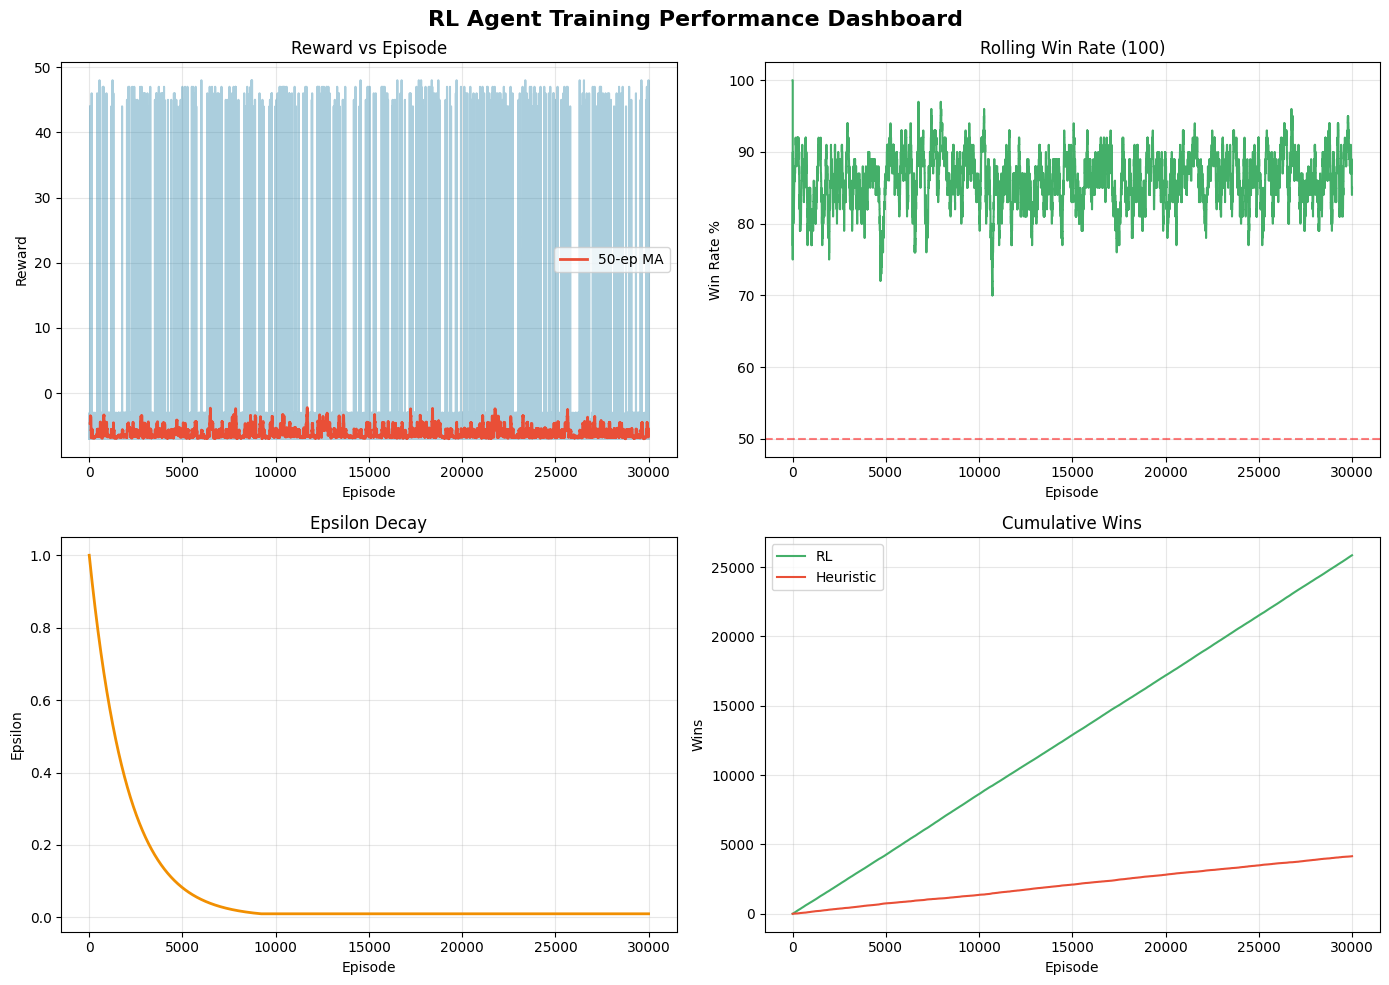

In [112]:
# All-in-One Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RL Agent Training Performance Dashboard', fontsize=16, fontweight='bold')

# Reward
ax1 = axes[0, 0]
ax1.plot(df['episode'], df['reward'], alpha=0.4, color='#2E86AB')
rolling = df['reward'].rolling(50).mean()
ax1.plot(df['episode'], rolling, color='#E94F37', linewidth=2, label='50-ep MA')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.set_title('Reward vs Episode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Win Rate
ax2 = axes[0, 1]
ax2.plot(df['episode'], df['rolling_win_rate']*100, color='#44AF69')
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Win Rate %')
ax2.set_title('Rolling Win Rate (100)')
ax2.grid(True, alpha=0.3)

# Epsilon
ax3 = axes[1, 0]
ax3.plot(df['episode'], df['epsilon'], color='#F18F01', linewidth=2)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Epsilon')
ax3.set_title('Epsilon Decay')
ax3.grid(True, alpha=0.3)

# Cumulative Wins
ax4 = axes[1, 1]
ax4.plot(df['episode'], df['rl_wins'], color='#44AF69', label='RL')
ax4.plot(df['episode'], df['heuristic_wins'], color='#E94F37', label='Heuristic')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Wins')
ax4.set_title('Cumulative Wins')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()